# REBA Projesi - Veri, Model Performansı ve Güvenilirlik Analizi

Bu notebook projenin veri işleme hattını **yeniden üretilebilir** biçimde inceler. Hazır metrik CSV'sine güvenmek yerine:

1. Arşivlenmiş 90 boyutlu özelliği ve 19 gerçek açı hedefini yükler.
2. Test satırlarını eğitim havuzundan hash ile ayırarak veri sızıntısını kontrol eder.
3. Üretimde kullanılan Extra Trees modelini diskten yükleyip test tahminlerini yeniden üretir.
4. Eski FT-Transformer ile aynı test örnekleri ve aynı hedefler üzerinde karşılaştırma yapar.
5. R², MAE ve RMSE değerlerini hedef bazında ve makro ortalama olarak hesaplar.
6. Artık dağılımları, gerçek-tahmin grafikleri ve özellik önemlerini gösterir.

> **Önemli sınır:** Arşiv kişi, sekans ve kamera kimliği taşımıyor. Satır bazlı test ayrımı doğrulansa da kişi/video bağımsızlığı kanıtlanamaz. Bu notebook açı regresyonunu değerlendirir; uzman etiketli nihai REBA skorları bulunmadığı için saha REBA doğruluğunu tek başına kanıtlamaz.


In [1]:
from pathlib import Path
import json, warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 100)
np.random.seed(42)
ROOT = Path.cwd()
if not (ROOT / "BestModel").exists():
    raise FileNotFoundError("Run this notebook from the project root.")
print("Project root:", ROOT)


Project root: C:\Users\Acer\OneDrive\Belgeler\TÜBİTAK 2209-B\Öğrencilere


## 1. Projenin veri ve işlem hattı

### Canlı çıkarım hattı

```text
Görüntü / Video / Webcam
        ↓
MediaPipe Pose 33 → görünür 2B noktalar + göreli 3B dünya noktaları
        ↓
Görünür REBA açıları → boyun, gövde, kol, dirsek, bilek, diz, ayak
        ├── YOLO11 Pose → eski 90 özellik sözleşmesi
        └── Extra Trees → 19 ikincil/gizli açı tahmini
        ↓
Merkezî REBA Motoru → Tablo A + B + C
        + yük / kavrama / aktivite / manuel duruş modifikatörleri
        ↓
1-15 REBA skoru + risk sınıfı + açıklama
```

### Eğitim arşivinin anlamı

`advanced_ft_transformer_predictions_all.csv` dosyasında `0..89` standardize edilmiş anonim girdiler, `*_true` gerçek hedefler ve `*_pred` eski FT-Transformer tahminleri bulunur. Yeni model, REBA açısından anlamlı 19 açı hedefinde değerlendirilmiştir; tanımlanması zayıf quaternion hedefleri model seçimine dahil edilmemiştir.


In [2]:
ALL_PATH = ROOT / "BestModel" / "advanced_ft_transformer_predictions_all.csv"
TEST_PATH = ROOT / "BestModel" / "advanced_ft_transformer_predictions_test.csv"
MODEL_PATH = ROOT / "ModelExperiments" / "extra_trees.joblib"
MANIFEST_PATH = ROOT / "ModelExperiments" / "manifest.json"
ANGLE_TARGETS = [
    "elbowL_yz_deg", "elbowR_yz_deg", "head_vs_neck_xz_deg", "head_vs_neck_yz_deg",
    "kneeL_xz_deg", "kneeL_yz_deg", "kneeR_xz_deg", "kneeR_yz_deg",
    "shoulderL_vs_upperarmL_xz_deg", "shoulderL_vs_upperarmL_yz_deg",
    "shoulderR_vs_upperarmR_xz_deg", "shoulderR_vs_upperarmR_yz_deg",
    "spine1_vs_spine2_yz_deg", "spine2_vs_spine3_yz_deg", "spine3_vs_spine4_yz_deg",
    "thighL_vs_spine1_yz_deg", "thighR_vs_spine1_yz_deg", "wristL_yz_deg", "wristR_yz_deg",
]
FEATURE_COLS = [str(i) for i in range(90)]
TRUE_COLS = [f"{x}_true" for x in ANGLE_TARGETS]
OLD_PRED_COLS = [f"{x}_pred" for x in ANGLE_TARGETS]
all_df = pd.read_csv(ALL_PATH); test_df = pd.read_csv(TEST_PATH)
manifest = json.loads(MANIFEST_PATH.read_text(encoding="utf-8"))
test_hash = pd.util.hash_pandas_object(test_df[FEATURE_COLS], index=False)
all_hash = pd.util.hash_pandas_object(all_df[FEATURE_COLS], index=False)
train_df = all_df.loc[~all_hash.isin(set(test_hash))].copy()
print(f"Archive rows: {len(all_df):,}")
print(f"Training rows after leakage removal: {len(train_df):,}")
print(f"Independent test rows: {len(test_df):,}")
print(f"Features / targets: {len(FEATURE_COLS)} / {len(TRUE_COLS)}")
print("Training augmentation:", manifest["augmentation"])


Archive rows: 2,400
Training rows after leakage removal: 1,920
Independent test rows: 480
Features / targets: 90 / 19
Training augmentation: {'copies': 1, 'gaussian_noise_std': 0.015}


In [3]:
quality = pd.DataFrame({
    "train_missing": train_df[FEATURE_COLS + TRUE_COLS].isna().sum(),
    "test_missing": test_df[FEATURE_COLS + TRUE_COLS].isna().sum(),
})
print("Total missing values:", int(quality.to_numpy().sum()))
train_hash = pd.util.hash_pandas_object(train_df[FEATURE_COLS], index=False)
print("Exact test rows remaining in train:", int(test_hash.isin(set(train_hash)).sum()))
print("Duplicate train feature rows:", int(train_df.duplicated(FEATURE_COLS).sum()))
print("Duplicate test feature rows:", int(test_df.duplicated(FEATURE_COLS).sum()))
target_stats = train_df[TRUE_COLS].describe().T[["mean","std","min","max"]]
target_stats.index = ANGLE_TARGETS
target_stats.round(2)


Total missing values: 0


Exact test rows remaining in train: 0
Duplicate train feature rows: 0
Duplicate test feature rows: 0


,mean,std,min,max
elbowL_yz_deg,152.38,32.90,27.32,179.62
elbowR_yz_deg,151.71,34.08,21.51,179.99
head_vs_neck_xz_deg,9.31,19.97,0.08,175.34
head_vs_neck_yz_deg,20.98,12.92,0.32,81.01
kneeL_xz_deg,148.00,47.26,4.74,178.94
kneeL_yz_deg,118.28,45.02,15.76,179.89
kneeR_xz_deg,148.94,43.24,0.64,179.73
kneeR_yz_deg,118.18,44.90,22.11,179.98
shoulderL_vs_upperarmL_xz_deg,68.82,32.72,0.39,166.96
shoulderL_vs_upperarmL_yz_deg,86.00,44.39,0.63,179.71


## 2. Modellerin aynı test kümesinde yeniden çalıştırılması

Karşılaştırmada iki model de **aynı 480 test satırı** ve **aynı 19 açı hedefi** üzerinde değerlendirilir:

- **Eski model:** Arşivdeki FT-Transformer `*_pred` kolonları.
- **Yeni model:** `extra_trees.joblib` dosyası yüklenerek notebook içinde yeniden tahmin edilir.

R² hedef varyansının açıklanan oranını, MAE ortalama mutlak derece hatasını, RMSE ise büyük hatalara daha fazla ceza veren derece hatasını gösterir.


In [4]:
X_test = test_df[FEATURE_COLS].to_numpy(np.float32)
y_true = test_df[TRUE_COLS].to_numpy(np.float32)
y_old = test_df[OLD_PRED_COLS].to_numpy(np.float32)
model = joblib.load(MODEL_PATH)
y_new = model.predict(X_test)
print("Model type:", type(model).__name__)
print("Prediction shape:", y_new.shape)
print("Finite prediction ratio:", np.isfinite(y_new).mean())


Model type: ExtraTreesRegressor
Prediction shape: (480, 19)
Finite prediction ratio: 1.0


In [5]:
def metric_table(y, pred, model_name):
    rows = []
    for i, target in enumerate(ANGLE_TARGETS):
        rows.append({
            "model": model_name,
            "target": target,
            "r2": r2_score(y[:, i], pred[:, i]),
            "mae_deg": mean_absolute_error(y[:, i], pred[:, i]),
            "rmse_deg": mean_squared_error(y[:, i], pred[:, i]) ** 0.5,
            "p90_abs_error_deg": np.percentile(np.abs(y[:, i]-pred[:, i]), 90),
        })
    return pd.DataFrame(rows)

metrics_old = metric_table(y_true, y_old, "Eski FT-Transformer")
metrics_new = metric_table(y_true, y_new, "Yeni Extra Trees")
metrics = pd.concat([metrics_old, metrics_new], ignore_index=True)

summary = metrics.groupby("model").agg(
    macro_r2=("r2", "mean"),
    median_r2=("r2", "median"),
    macro_mae_deg=("mae_deg", "mean"),
    macro_rmse_deg=("rmse_deg", "mean"),
    mean_p90_abs_error_deg=("p90_abs_error_deg", "mean"),
    positive_r2_targets=("r2", lambda x: int((x > 0).sum())),
).sort_values("macro_r2", ascending=False)
summary.round(3)


,macro_r2,median_r2,macro_mae_deg,macro_rmse_deg,mean_p90_abs_error_deg,positive_r2_targets
model,,,,,,
Yeni Extra Trees,0.615,0.628,11.677,17.440,26.033,19
Eski FT-Transformer,0.399,0.328,15.076,21.753,33.535,19


In [6]:
comparison = metrics_new.merge(metrics_old, on="target", suffixes=("_new","_old"))
comparison["r2_gain"] = comparison["r2_new"] - comparison["r2_old"]
comparison["mae_improvement_deg"] = comparison["mae_deg_old"] - comparison["mae_deg_new"]
comparison[["target","r2_old","r2_new","r2_gain","mae_deg_old","mae_deg_new","rmse_deg_new"]].sort_values("r2_new", ascending=False).round(3)


,target,r2_old,r2_new,r2_gain,mae_deg_old,mae_deg_new,rmse_deg_new
6,kneeR_xz_deg,0.747,0.809,0.062,11.434000,10.506,18.168
5,kneeL_yz_deg,0.709,0.791,0.082,15.992000,13.640,20.042
7,kneeR_yz_deg,0.708,0.782,0.074,16.371000,13.880,20.387
4,kneeL_xz_deg,0.683,0.773,0.090,11.731000,10.884,21.506
15,thighL_vs_spine1_yz_deg,0.568,0.766,0.198,16.729000,12.466,17.560
16,thighR_vs_spine1_yz_deg,0.578,0.758,0.180,17.546000,12.544,18.314
11,shoulderR_vs_upperarmR_yz_deg,0.541,0.739,0.198,23.903999,17.634,22.863
9,shoulderL_vs_upperarmL_yz_deg,0.498,0.672,0.174,24.365000,18.768,25.804
12,spine1_vs_spine2_yz_deg,0.328,0.659,0.331,4.839000,3.524,6.690
8,shoulderL_vs_upperarmL_xz_deg,0.318,0.628,0.310,20.974001,14.815,20.459


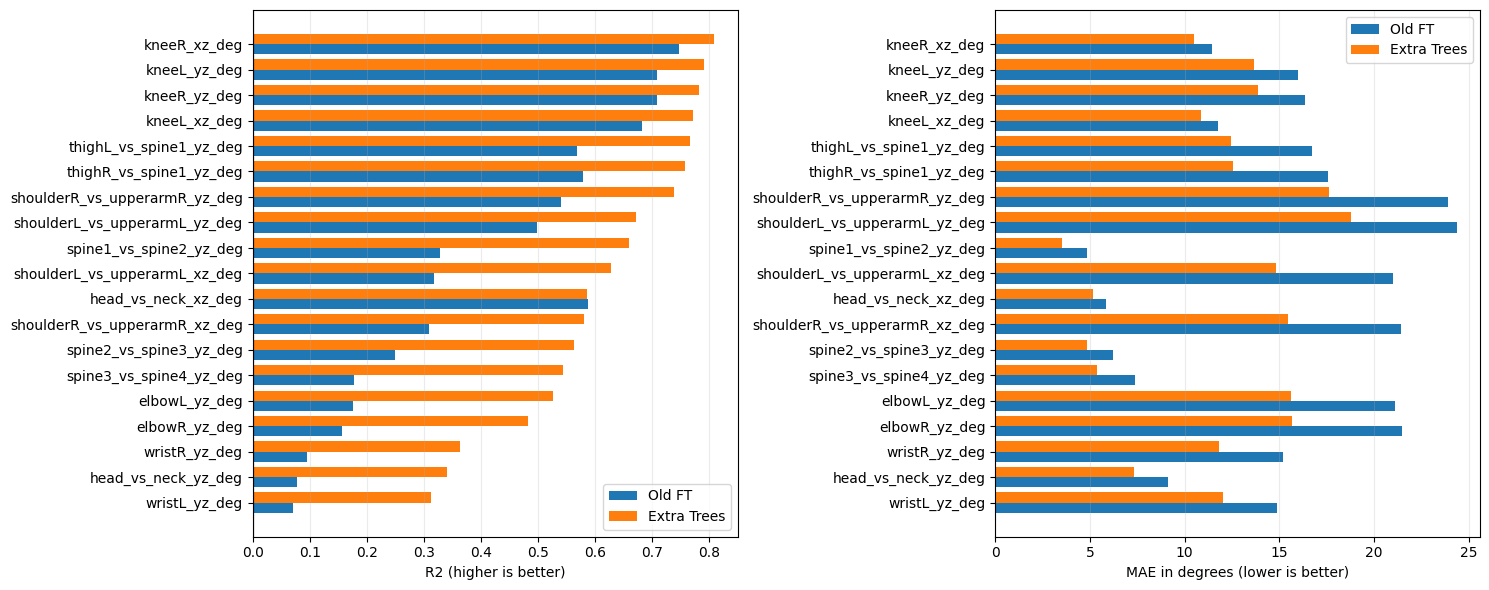

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
order = comparison.sort_values("r2_new")["target"]
ypos = np.arange(len(order)); plot_df = comparison.set_index("target").loc[order]
axes[0].barh(ypos-0.2, plot_df["r2_old"], height=0.4, label="Old FT")
axes[0].barh(ypos+0.2, plot_df["r2_new"], height=0.4, label="Extra Trees")
axes[0].set_yticks(ypos, order); axes[0].set_xlabel("R2 (higher is better)")
axes[0].axvline(0, color="black", lw=.8); axes[0].legend(); axes[0].grid(axis="x", alpha=.25)
axes[1].barh(ypos-0.2, plot_df["mae_deg_old"], height=0.4, label="Old FT")
axes[1].barh(ypos+0.2, plot_df["mae_deg_new"], height=0.4, label="Extra Trees")
axes[1].set_yticks(ypos, order); axes[1].set_xlabel("MAE in degrees (lower is better)")
axes[1].legend(); axes[1].grid(axis="x", alpha=.25)
plt.tight_layout(); plt.show()


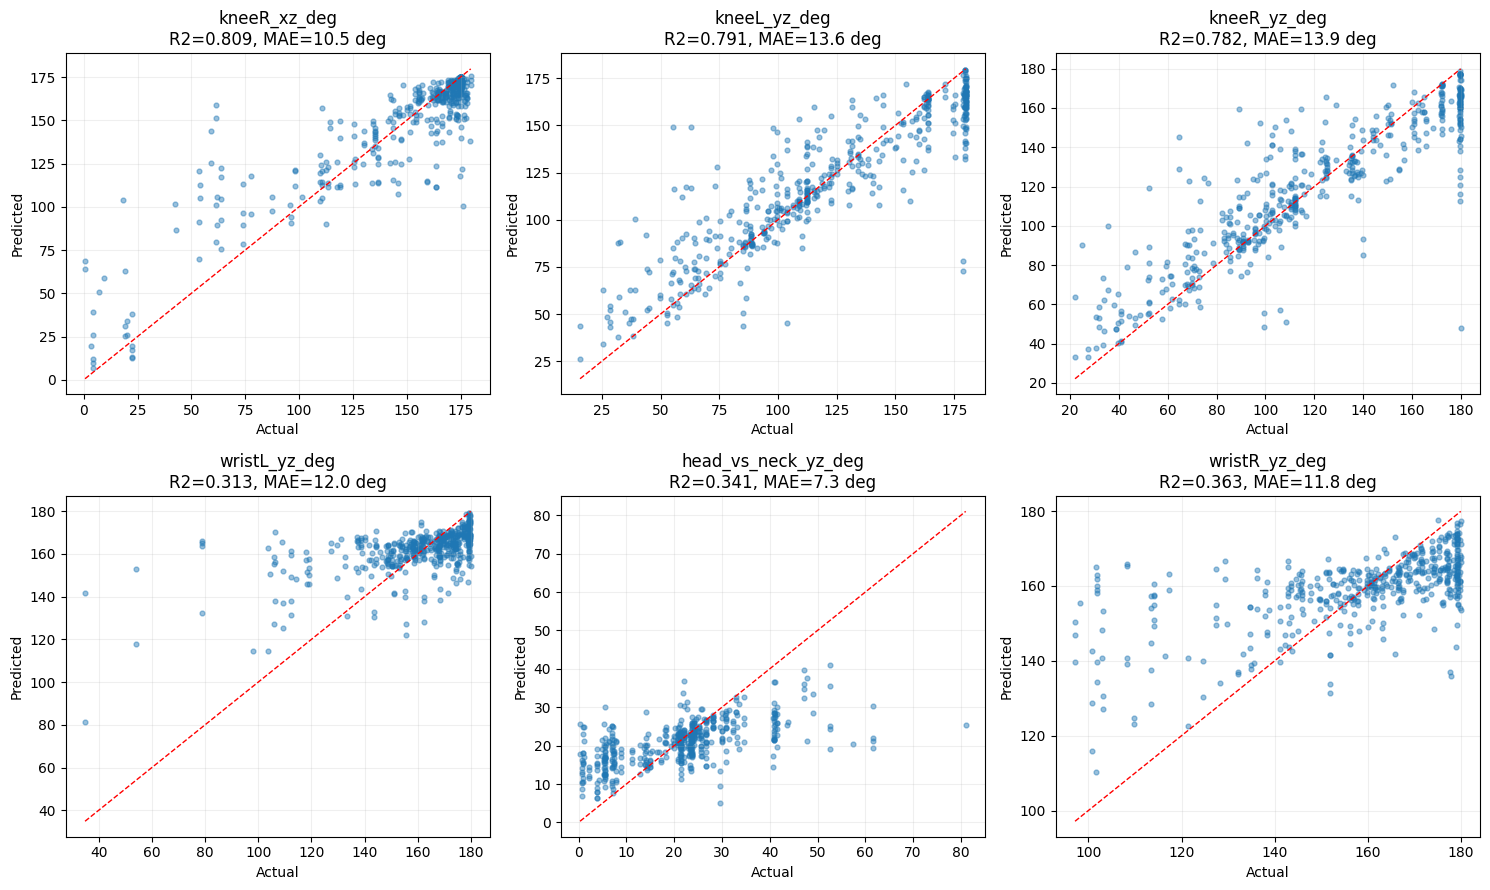

In [8]:
selected = list(comparison.nlargest(3, "r2_new")["target"]) + list(comparison.nsmallest(3, "r2_new")["target"])
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, target in zip(axes.ravel(), selected):
    i = ANGLE_TARGETS.index(target)
    ax.scatter(y_true[:,i], y_new[:,i], s=12, alpha=.45)
    lo = min(y_true[:,i].min(), y_new[:,i].min()); hi = max(y_true[:,i].max(), y_new[:,i].max())
    ax.plot([lo,hi],[lo,hi], "r--", lw=1)
    r2 = r2_score(y_true[:,i], y_new[:,i]); mae = mean_absolute_error(y_true[:,i], y_new[:,i])
    ax.set_title(f"{target}\nR2={r2:.3f}, MAE={mae:.1f} deg")
    ax.set_xlabel("Actual"); ax.set_ylabel("Predicted"); ax.grid(alpha=.2)
plt.tight_layout(); plt.show()


Absolute error quantiles in degrees
0.50     6.87
0.75    15.39
0.90    28.04
0.95    39.65
0.99    66.99
Name: absolute_error_deg, dtype: float64


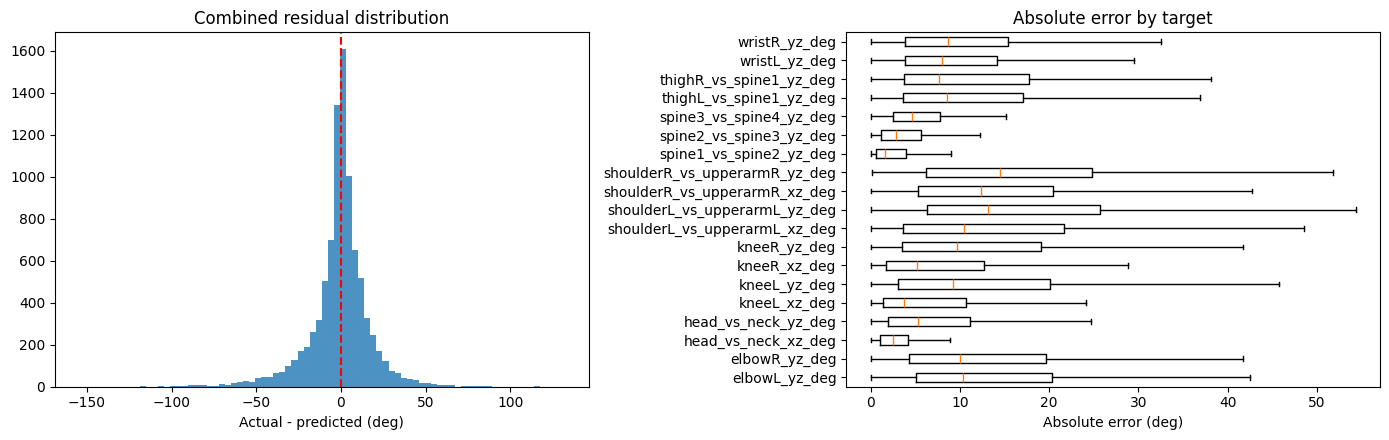

In [9]:
abs_error = np.abs(y_true-y_new)
flat = pd.Series(abs_error.ravel(), name="absolute_error_deg")
print("Absolute error quantiles in degrees")
print(flat.quantile([0.50,0.75,0.90,0.95,0.99]).round(2))
fig, axes = plt.subplots(1,2,figsize=(14,4.5))
axes[0].hist((y_true-y_new).ravel(), bins=80, alpha=.8)
axes[0].axvline(0,color="red",ls="--"); axes[0].set_title("Combined residual distribution"); axes[0].set_xlabel("Actual - predicted (deg)")
axes[1].boxplot([abs_error[:,i] for i in range(19)], vert=False, labels=ANGLE_TARGETS, showfliers=False)
axes[1].set_title("Absolute error by target"); axes[1].set_xlabel("Absolute error (deg)")
plt.tight_layout(); plt.show()


## 3. Model neyi kullanıyor?

Extra Trees, 90 standardize girdiyi kullanan çok çıktılı bir ağaç topluluğudur. Her ağaç özellik uzayının farklı bölünmelerini öğrenir ve nihai tahmin ağaçların ortalamasıdır. Aşağıdaki önem değerleri modelin hangi **özellik indekslerine** daha sık dayandığını gösterir.

Arşivde 90 özelliğin semantik adları korunmadığı için bunları anatomik nokta adı gibi yorumlamak doğru değildir. Gelecekte özellik adları, normalizasyon parametreleri ve veri şeması birlikte kaydedilmelidir.


Number of trees: 200
Minimum leaf samples: 2
Max feature ratio: 0.8
Importance captured by top 20 features: 0.568


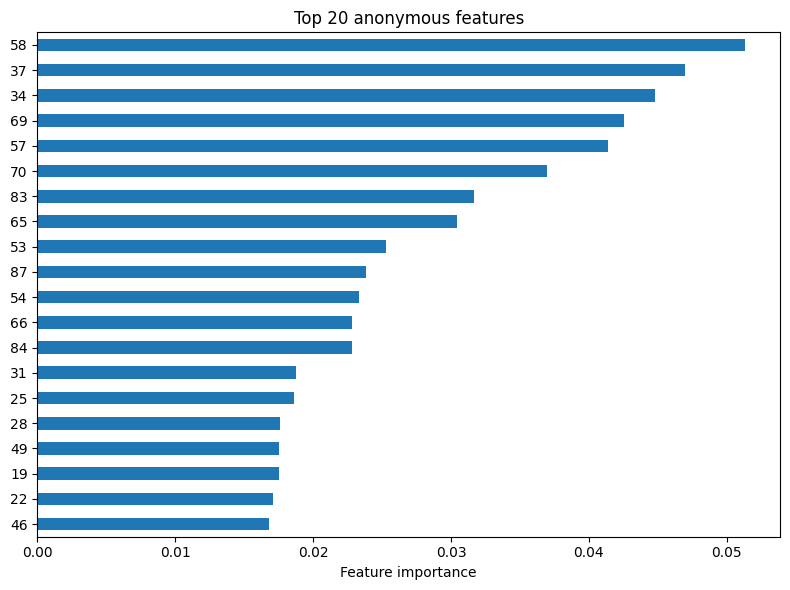

,importance
58,0.051304
37,0.046988
34,0.044816
69,0.042575
57,0.041359
70,0.036930
83,0.031661
65,0.030416
53,0.025281
87,0.023806


In [10]:
params = model.get_params()
print("Number of trees:", params.get("n_estimators"))
print("Minimum leaf samples:", params.get("min_samples_leaf"))
print("Max feature ratio:", params.get("max_features"))
importance = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print("Importance captured by top 20 features:", round(float(importance.head(20).sum()), 3))
importance.head(20).sort_values().plot.barh(figsize=(8,6), title="Top 20 anonymous features")
plt.xlabel("Feature importance"); plt.tight_layout(); plt.show()
importance.head(20).to_frame("importance")


## 4. Güvenilirlik yorumu

### Güçlü kanıtlar

- Test satırları eğitim havuzundan birebir özellik hash'iyle çıkarılmıştır.
- Yeni modelin 19 hedefinin tamamında R² pozitiftir.
- Yeni model eski FT-Transformer'dan R², MAE ve RMSE açısından daha iyidir.
- Diz ve uyluk/gövde açıları yaklaşık `R²=0.75-0.81` bandında en güçlü hedeflerdir.

### Zayıf alanlar

- Bilek ve baş-boyun YZ hedefleri yaklaşık `R²=0.31-0.36` ile zayıftır.
- Yaklaşık `11.7°` ortalama hata, REBA'nın 15°/20° eşiklerinin yakınında sınıf değişimine yol açabilir.
- Kişi, video, kamera ve sentetik/gerçek alan kimliği bulunmadığından grup bazlı bağımsız test yapılamıyor.
- 90 özellik anonimdir; ham landmark sözleşmesi arşivde yoktur.
- Açı doğruluğu nihai REBA doğruluğu ile aynı değildir. Nihai REBA için uzmanlarca puanlanmış gerçek saha kareleri gerekir.

### Sonuç

Model araştırma prototipi olarak yararlıdır; sertifikalı ergonomik ölçüm veya tek başına iş güvenliği kararı için yeterli değildir. Görünür MediaPipe geometrisi birincil, öğrenilmiş 19 açı ikincil bilgi olarak kullanılmalıdır.


In [11]:
best = comparison.sort_values("r2_new", ascending=False).iloc[0]
worst = comparison.sort_values("r2_new", ascending=True).iloc[0]
print(f"Strongest target: {best.target} | R2={best.r2_new:.3f} | MAE={best.mae_deg_new:.2f} deg")
print(f"Weakest target: {worst.target} | R2={worst.r2_new:.3f} | MAE={worst.mae_deg_new:.2f} deg")
print(f"Macro R2 gain: {summary.loc['Yeni Extra Trees','macro_r2']-summary.loc['Eski FT-Transformer','macro_r2']:+.3f}")
print(f"MAE improvement: {summary.loc['Eski FT-Transformer','macro_mae_deg']-summary.loc['Yeni Extra Trees','macro_mae_deg']:.2f} deg")


Strongest target: kneeR_xz_deg | R2=0.809 | MAE=10.51 deg
Weakest target: wristL_yz_deg | R2=0.313 | MAE=12.01 deg
Macro R2 gain: +0.216
MAE improvement: 3.40 deg


## 5. Bir sonraki doğrulama planı

1. Gerçek görüntüleri kişi, video, kamera ve görev kimliğiyle kaydet.
2. Bölmeyi kare bazında değil kişi ve sekans bazında yap.
3. En az iki ergonomistin kör ve bağımsız REBA etiketlerini topla; değerlendiriciler arası uyumu raporla.
4. Açı MAE/RMSE/R² yanında nihai REBA için exact accuracy, ±1 skor doğruluğu, ağırlıklı Cohen kappa ve risk sınıfı confusion matrix hesapla.
5. Sentetik ve gerçek test sonuçlarını ayrı raporla.
6. Bilek ve boyun hedefleri için daha yoğun gerçek veri ve kamera açısı çeşitliliği topla.
7. REBA eşiklerine yakın örneklerde belirsizlik uyarısı göster ve tek kare yerine kısa zaman penceresi kullan.

Bu adımlar tamamlanmadan model için “saha doğruluğu kanıtlandı” ifadesi kullanılmamalıdır.
